# Fence-area 311 overlay (2021–2026)

Rebuild the gateway fence `df` with public 311 illegal-dumping reports from **2021 through partial 2026**. Fit the Tacony Cox-Hawkes seasonal component on 2021–2024, then overlay fence-area observed avg/day.

1. Observed avg/day by month with a common pre-intervention baseline (VERSION 2, including model `f_a`)
2. Month-by-month comparison vs the historical same-month average

Intervention is **June 2025**. 2026 is partial; incomplete months use elapsed days, and future months are not filled with zeros.


In [20]:
import os
os.chdir("/Users/yuxin/Dropbox/DDDI/Illegal-Dumping")
os.environ["JAX_PLATFORM_NAME"] = "cpu"

import sys
bstpp_module_dir = os.path.abspath("/Users/yuxin/BSTPP")
if bstpp_module_dir not in sys.path:
    sys.path.insert(0, bstpp_module_dir)

import calendar
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpyro.distributions as dist
from shapely.geometry import Point, MultiPoint
from scipy import stats
from scipy.optimize import curve_fit

import bstpp
from bstpp.main import Hawkes_Model
from bstpp.trigger import Temporal_Power_Law

np.random.seed(999)
print("bstpp:", bstpp.__file__)

YEARS = list(range(2021, 2027))
INTERVENTION_YEAR = 2025
INTERVENTION_MONTH = 6
FENCE_BUFFER_M = 150
PARK_NAME = "tacony_box"
MODEL_START = pd.Timestamp("2021-01-01")
OFFSET_SEASONAL = 0


bstpp: /Users/yuxin/BSTPP/bstpp/__init__.py


## Fence polygon and buffer

/var/folders/nr/q7sysy9j07x_5smd2gfx3j380000gn/T/ipykernel_1803/1836153201.py:30: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  park_geom = tacony_park.unary_union


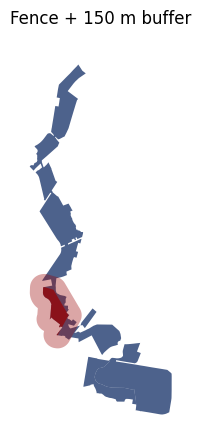

In [21]:
fence_point = "40.021707, -75.112372"
fence_point2 = "40.022489, -75.111869"
fence_point3 = "40.023520, -75.112041"
fence_point4 = "40.022518, -75.112038"
fence_point5 = "40.026709, -75.114394"
fence_point6 = "40.026388, -75.112939"
fence_point7 = "40.026045, -75.114667"
fence_point8 = "40.022313, -75.114887"
fence_point9 = "40.021759, -75.112816"
fence_point10 = "40.023762, -75.110918"

def to_lonlat(pt):
    lat, lon = map(float, pt.split(","))
    return (lon, lat)

pts_str = [
    fence_point, fence_point2, fence_point3, fence_point4, fence_point5,
    fence_point6, fence_point7, fence_point8, fence_point9, fence_point10
]
points = [Point(to_lonlat(s)) for s in pts_str]

fence_plg = gpd.GeoSeries([MultiPoint(points).convex_hull], crs="EPSG:4326")
fence_plg_gdf = gpd.GeoDataFrame(geometry=fence_plg.to_crs("EPSG:26918"), crs="EPSG:26918")

all_parks = gpd.read_file("output/all_parks_gdf.geojson").to_crs("EPSG:26918")
if "PARKNAME" in all_parks.columns:
    tacony_park = all_parks[all_parks["PARKNAME"] == "tacony"]
else:
    tacony_park = all_parks[all_parks["PARENT_NAME"] == "Tacony Creek Park"]
park_geom = tacony_park.unary_union
fence_plg_gdf["geometry"] = fence_plg_gdf.geometry.intersection(park_geom)
fence_plg_gdf = fence_plg_gdf[~fence_plg_gdf.is_empty & fence_plg_gdf.geometry.notna()].copy()

fence_buffer_gdf = gpd.GeoDataFrame(
    geometry=fence_plg_gdf.buffer(FENCE_BUFFER_M),
    crs="EPSG:26918"
)

fig, ax = plt.subplots(figsize=(3, 5))
tacony_park.plot(ax=ax, color="#011f5b", alpha=0.7)
fence_plg_gdf.plot(ax=ax, color="#990000", alpha=0.7)
fence_buffer_gdf.plot(ax=ax, color="#990000", alpha=0.35)
ax.set_axis_off()
ax.set_title("Fence + 150 m buffer")
plt.show()


## Rebuild `df`: 311 illegal dumping inside the fence buffer (2021–2026)

In [22]:
frames = []
for year in YEARS:
    path = f"data/311/{year}/public_cases_fc.shp"
    print(f"Loading {path} ...")
    gdf = gpd.read_file(path)
    dumping = gdf[gdf["service_na"] == "Illegal Dumping"].copy()
    dumping = dumping.to_crs(epsg=26918)
    dumping["source_year"] = year
    print(f"  {year}: {len(dumping):,} illegal dumping reports")
    frames.append(dumping)

illegal_dumping = gpd.GeoDataFrame(pd.concat(frames, ignore_index=True), crs="EPSG:26918")
illegal_dumping["requested_"] = pd.to_datetime(illegal_dumping["requested_"], errors="coerce")
illegal_dumping = illegal_dumping.dropna(subset=["requested_"]).copy()
print(f"Citywide total: {len(illegal_dumping):,}")

df = illegal_dumping.sjoin(fence_buffer_gdf, predicate="within")
if "index_right" in df.columns:
    df = df.drop(columns=["index_right"])
df = df[df["requested_"].dt.year.between(min(YEARS), max(YEARS))].copy()
df["year"] = df["requested_"].dt.year
df["month"] = df["requested_"].dt.month

print(f"Fence-buffer reports: {len(df):,}")
print(f"Date range: {df['requested_'].min().date()} to {df['requested_'].max().date()}")
print(df.groupby("year").size().rename("n"))


Loading data/311/2021/public_cases_fc.shp ...
  2021: 25,375 illegal dumping reports
Loading data/311/2022/public_cases_fc.shp ...
  2022: 24,037 illegal dumping reports
Loading data/311/2023/public_cases_fc.shp ...
  2023: 22,590 illegal dumping reports
Loading data/311/2024/public_cases_fc.shp ...
  2024: 22,173 illegal dumping reports
Loading data/311/2025/public_cases_fc.shp ...
  2025: 22,651 illegal dumping reports
Loading data/311/2026/public_cases_fc.shp ...
  2026: 8,196 illegal dumping reports
Citywide total: 125,022
Fence-buffer reports: 269
Date range: 2021-02-17 to 2026-07-22
year
2021    42
2022    51
2023    54
2024    64
2025    44
2026    14
Name: n, dtype: int64


## Monthly avg/day

In [23]:
df_plot = df.copy()
last_obs = df_plot["requested_"].max()
last_complete = (last_obs.replace(day=1) - pd.offsets.MonthBegin(1))
print(f"Last observed report: {last_obs.date()}")
print(f"Last complete month:  {last_complete.strftime('%Y-%m')}")

monthly_counts = (
    df_plot.groupby([df_plot["requested_"].dt.year.rename("year"),
                     df_plot["requested_"].dt.month.rename("month")])
    .size()
    .reset_index(name="n")
)

elapsed_pairs = []
for year in YEARS:
    for month in range(1, 13):
        ym = pd.Timestamp(year=year, month=month, day=1)
        if ym <= last_complete:
            elapsed_pairs.append((year, month))
        elif year == last_obs.year and month == last_obs.month:
            elapsed_pairs.append((year, month))

all_year_month = pd.MultiIndex.from_tuples(elapsed_pairs, names=["year", "month"])
monthly_counts = (
    monthly_counts
    .set_index(["year", "month"])
    .reindex(all_year_month, fill_value=0)
    .reset_index()
)

def days_for_avg(row, last_obs=last_obs):
    year, month = int(row["year"]), int(row["month"])
    if year == last_obs.year and month == last_obs.month:
        return int(last_obs.day)
    return calendar.monthrange(year, month)[1]

monthly_counts["days_in_month"] = monthly_counts.apply(days_for_avg, axis=1)
monthly_counts["avg_per_day"] = monthly_counts["n"] / monthly_counts["days_in_month"]
monthly_counts["month_centered"] = monthly_counts["month"] - INTERVENTION_MONTH
monthly_counts["incomplete"] = (
    (monthly_counts["year"] == last_obs.year)
    & (monthly_counts["month"] == last_obs.month)
)

obs = monthly_counts.copy()

obs_pre_intervention = obs[
    (obs["year"] < INTERVENTION_YEAR)
    | ((obs["year"] == INTERVENTION_YEAR) & (obs["month"] < INTERVENTION_MONTH))
].copy()
obs_post_intervention_historical = obs[
    (obs["year"] < INTERVENTION_YEAR) & (obs["month"] >= INTERVENTION_MONTH)
].copy()
obs_post_intervention_2025 = obs[
    (obs["year"] == INTERVENTION_YEAR) & (obs["month"] >= INTERVENTION_MONTH)
].copy()
obs_post_intervention_2026 = obs[obs["year"] == 2026].copy()

pre_summary = obs_pre_intervention.groupby("month_centered")["avg_per_day"].agg(
    mean="mean", std="std", n="size"
).reset_index()
post_historical_summary = obs_post_intervention_historical.groupby("month_centered")["avg_per_day"].agg(
    mean="mean", std="std", n="size"
).reset_index()

months_centered = np.arange(1, 13) - INTERVENTION_MONTH
month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

print(obs.tail(16).to_string(index=False))
print("Pre-intervention rows:", len(obs_pre_intervention))
print("Post 2025 Jun-Dec:", len(obs_post_intervention_2025))
print("Post 2026 months:", obs_post_intervention_2026["month"].tolist())


Last observed report: 2026-07-22
Last complete month:  2026-06
 year  month  n  days_in_month  avg_per_day  month_centered  incomplete
 2025      4  4             30     0.133333              -2       False
 2025      5  2             31     0.064516              -1       False
 2025      6  5             30     0.166667               0       False
 2025      7  4             31     0.129032               1       False
 2025      8  8             31     0.258065               2       False
 2025      9  7             30     0.233333               3       False
 2025     10  3             31     0.096774               4       False
 2025     11  1             30     0.033333               5       False
 2025     12  0             31     0.000000               6       False
 2026      1  7             31     0.225806              -5       False
 2026      2  0             28     0.000000              -4       False
 2026      3  1             31     0.032258              -3       False
 

## Hawkes seasonal component (Tacony, 2021–2026)

Same Cox-Hawkes specification as `cbg-park-seasonal_fence.ipynb`, but the temporal window now runs from **2021-01-01 through the last available 2026 report** (partial year). `f_a` is still the annual seasonal GP; `f_t` is the long-term GP on that same window. `f_a` is then rescaled to fence-area pre-intervention avg/day.



In [24]:
cov_gdf = gpd.read_file("output/cov_cbg.geojson").to_crs(epsg=26918)
all_boxes_gdf = gpd.read_file("output/all_boxes_gdf.geojson").to_crs(epsg=26918)
park_box = all_boxes_gdf[all_boxes_gdf["PARKNAME"] == PARK_NAME]

park_points = illegal_dumping[illegal_dumping["requested_"] >= MODEL_START].sjoin(
    park_box, predicate="within"
)
if "index_right" in park_points.columns:
    park_points = park_points.drop(columns=["index_right"])
park_points = park_points.sjoin(cov_gdf, predicate="within", how="inner")
if "index_right" in park_points.columns:
    park_points = park_points.drop(columns=["index_right"])

min_time = MODEL_START
tmax = park_points["requested_"].max()
TOTAL_DAYS = float((tmax.normalize() + pd.Timedelta(days=1) - min_time).days)
time = (park_points["requested_"] - min_time).dt.total_seconds() / (24 * 60 * 60)
park_points = park_points[(time >= 0) & (time <= TOTAL_DAYS)].copy()
time = (park_points["requested_"] - min_time).dt.total_seconds() / (24 * 60 * 60)
seasonal = (time + OFFSET_SEASONAL) % 365

locs_s = pd.DataFrame({
    "X": park_points.geometry.centroid.x.astype(float),
    "Y": park_points.geometry.centroid.y.astype(float),
    "T": time.astype(float),
    "A": seasonal.astype(float),
})
print(
    f"locs_s for Hawkes fit: {len(locs_s):,} points, "
    f"T in [{locs_s['T'].min():.1f}, {locs_s['T'].max():.1f}], "
    f"TOTAL_DAYS={TOTAL_DAYS:.0f} "
    f"({min_time.date()} to {(min_time + pd.Timedelta(days=TOTAL_DAYS)).date()})"
)


locs_s for Hawkes fit: 950 points, T in [1.0, 2050.0], TOTAL_DAYS=2051 (2021-01-01 to 2026-08-14)


[DEBUG] set_window called with:
  window type: <class 'float'> value: 100.0
  spatial_window type: <class 'float'> value: 0.1
[DEBUG] aligned_difference_pairs called with:
  t type: <class 'numpy.ndarray'> dtype: float64 shape: (950,)
  x type: <class 'numpy.ndarray'> dtype: float64 shape: (950,)
  y type: <class 'numpy.ndarray'> dtype: float64 shape: (950,)
  window type: <class 'float'> value: 100.0
  spatial_window type: <class 'float'> value: 0.1
[set_window] Temporal window set to: 100.0
[set_window] Number of events: 950
[set_window] Number of pairs: 27284
[set_window] Max t_diff in pairs: 49.53681131155533
[set_window] Min t_diff in pairs: 0.024378352023397554
[set_window] All t_diff <= window: True
[set_window] All t_diff > 0: True
[set_window] Spatial window set to: 0.1
[set_window] Max spatial distance: 0.09999199956655502
[set_window] Min spatial distance: 0.0
[set_window] All spatial distances <= window: True


100%|██████████| 10000/10000 [00:08<00:00, 1178.24it/s, init loss: 22887.4648, avg. loss [9501-10000]: -23420.2891]


Number of posterior samples: 1000
Number of pairs: 27284
coords shape: (27284, 2)

SVI elapsed time: 9.56045389175415


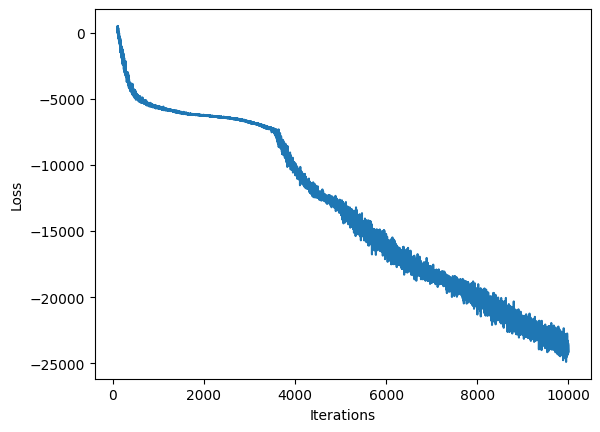

In [33]:
column_names = [
    "pop_density", "med_inc_avg", "lep_density", "edu_hs_avg", "ndvi_mean_4yr",
    "RLD", "RMD", "RHD", "use_com", "use_civ", "I", "T", "GW",
    "vac_area", "landcare_area",
    "alloc_avg_d_cnt", "alloc_avg_s_cnt", "unique_device_ratio_aw", "reporting_rate",
    "betweenness_avg_w", "pagerank_avg_w", "betweenness_avg_d", "pagerank_avg_d"
]

model = bstpp.main.Hawkes_Model(
    locs_s,
    park_box,
    TOTAL_DAYS,
    True,
    spatial_cov=cov_gdf,
    cov_names=column_names,
    standardize_cov=True,
    a_0=dist.Normal(0, 2),
    alpha=dist.Beta(2, 2),
    beta=dist.Exponential(1.0),
    gamma=dist.Exponential(1.0),
    sigmax_2=dist.HalfNormal(0.25),
    offset_seasonal=OFFSET_SEASONAL,
    temporal_trig=bstpp.trigger.Temporal_Power_Law
)

model.set_window(window=100, spatial_window=0.1)
model.run_svi(lr=0.01, num_steps=10000)


In [26]:
f_a_post = np.asarray(model.samples["f_a"])
fa_mean_grid = f_a_post.mean(axis=0)
fa_lo_grid = np.quantile(f_a_post, 0.05, axis=0)
fa_hi_grid = np.quantile(f_a_post, 0.95, axis=0)
S = float(model.args["S"])
offset = float(model.args["offset_seasonal"])
n_s = f_a_post.shape[1]

x_a = np.linspace(0, S, n_s, endpoint=False)
x_shift = (x_a + offset) % S

ref_year = 2021
month_lengths = np.array([calendar.monthrange(ref_year, m)[1] for m in range(1, 13)], dtype=float)
month_breaks = np.concatenate([[0.0], np.cumsum(month_lengths)])
month_breaks = month_breaks / month_breaks[-1] * S
grid_month = np.digitize(x_shift, month_breaks[1:-1], right=False) + 1

fa_mean_month = np.array([fa_mean_grid[grid_month == m].mean() for m in range(1, 13)])
fa_lo_month = np.array([fa_lo_grid[grid_month == m].mean() for m in range(1, 13)])
fa_hi_month = np.array([fa_hi_grid[grid_month == m].mean() for m in range(1, 13)])
months_centered = np.arange(1, 13) - 6

def linear_transform(x, scale, intercept):
    return scale * x + intercept

popt, _ = curve_fit(linear_transform, fa_mean_month, pre_summary["mean"])
scale_fit, offset_fit = popt
fa_mean_month_scaled = scale_fit * fa_mean_month + offset_fit
fa_lo_month_scaled = scale_fit * fa_lo_month + offset_fit
fa_hi_month_scaled = scale_fit * fa_hi_month + offset_fit
print(f"Model rescaling: scale={scale_fit:.3f}, offset={offset_fit:.3f}")
print("Months present in f_a grid:", np.unique(grid_month))

f_t_post = np.asarray(model.samples["f_t"])
ft_mean_grid = f_t_post.mean(axis=0)
ft_lo_grid = np.quantile(f_t_post, 0.05, axis=0)
ft_hi_grid = np.quantile(f_t_post, 0.95, axis=0)
n_t = f_t_post.shape[1]
x_t_internal = np.asarray(model.args["x_t"], dtype=float)
x_t_days = x_t_internal / float(model.args["T"]) * float(model.T)
ft_dates = MODEL_START + pd.to_timedelta(x_t_days, unit="D")

ft_grid = pd.DataFrame({
    "date": pd.to_datetime(ft_dates),
    "ft_mean": ft_mean_grid,
    "ft_lo": ft_lo_grid,
    "ft_hi": ft_hi_grid,
})
ft_grid["year"] = ft_grid["date"].dt.year
ft_grid["month"] = ft_grid["date"].dt.month
ft_month = (
    ft_grid.groupby(["year", "month"], as_index=False)
    .agg(ft_mean=("ft_mean", "mean"), ft_lo=("ft_lo", "mean"), ft_hi=("ft_hi", "mean"))
)
ft_month["date"] = pd.to_datetime(
    ft_month["year"].astype(str) + "-" + ft_month["month"].astype(str) + "-01"
)

pre_for_ft = obs_pre_intervention.merge(ft_month, on=["year", "month"], how="inner")
popt_t, _ = curve_fit(linear_transform, pre_for_ft["ft_mean"], pre_for_ft["avg_per_day"])
ft_scale_fit, ft_offset_fit = popt_t
ft_month["ft_mean_scaled"] = ft_scale_fit * ft_month["ft_mean"] + ft_offset_fit
ft_month["ft_lo_scaled"] = ft_scale_fit * ft_month["ft_lo"] + ft_offset_fit
ft_month["ft_hi_scaled"] = ft_scale_fit * ft_month["ft_hi"] + ft_offset_fit
print(f"f_t rescaling: scale={ft_scale_fit:.3f}, offset={ft_offset_fit:.3f}")
print(f"f_t window: {ft_month['date'].min().date()} to {ft_month['date'].max().date()} ({len(ft_month)} months)")



Model rescaling: scale=0.108, offset=0.166
Months present in f_a grid: [ 1  2  3  4  5  6  7  8  9 10 11 12]


## VERSION 2: Trended plot with merged pre-intervention baseline

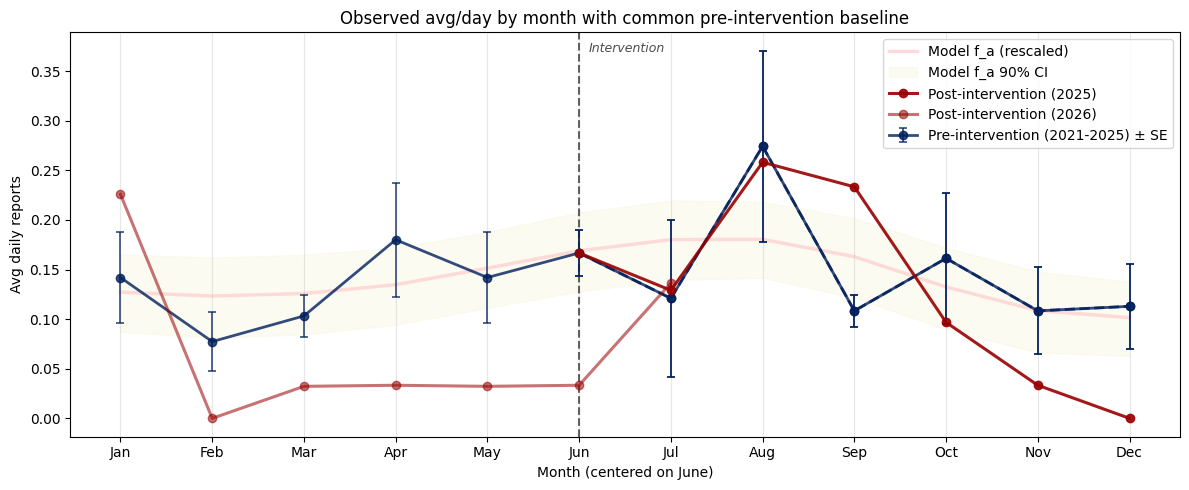

In [43]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    months_centered,
    fa_mean_month_scaled,
    linewidth=2.5,
    color="pink",
    alpha=0.6,
    label="Model f_a (rescaled)",
    zorder=1
)
ax.fill_between(
    months_centered,
    fa_lo_month_scaled,
    fa_hi_month_scaled,
    alpha=0.15,
    color="palegoldenrod",
    label="Model f_a 90% CI",
    zorder=1
)

ax.errorbar(
    pre_summary["month_centered"],
    pre_summary["mean"],
    yerr=pre_summary["std"] / np.sqrt(pre_summary["n"]),
    marker="o",
    label="Pre-intervention (2021-2025) ± SE",
    color="#011f5b",
    alpha=0.8,
    linewidth=2,
    capsize=3,
    capthick=1.2,
    elinewidth=1.2,
    zorder=3
)

ax.errorbar(
    post_historical_summary["month_centered"],
    post_historical_summary["mean"],
    yerr=post_historical_summary["std"] / np.sqrt(post_historical_summary["n"]),
    marker="o",
    color="#011f5b",
    alpha=0.8,
    linewidth=2,
    linestyle="--",
    capsize=3,
    capthick=1.2,
    elinewidth=1.2,
    zorder=3
)

ax.plot(
    obs_post_intervention_2025["month_centered"],
    obs_post_intervention_2025["avg_per_day"],
    marker="o",
    label="Post-intervention (2025)",
    color="#990000",
    alpha=0.9,
    linewidth=2.2,
    zorder=4
)

ax.plot(
    obs_post_intervention_2026["month_centered"],
    obs_post_intervention_2026["avg_per_day"],
    marker="o",
    label="Post-intervention (2026)",
    color="#990000",
    alpha=0.55,
    linewidth=2.2,
    zorder=4
)

ax.axvline(0, color="black", linestyle="--", linewidth=1.5, alpha=0.6)
ax.text(0.1, ax.get_ylim()[1] * 0.95, "Intervention",
        fontsize=9, style="italic", alpha=0.7)

ax.set_xlabel("Month (centered on June)")
ax.set_ylabel("Avg daily reports")

month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
ax.set_xticks(months_centered)
ax.set_xticklabels(month_labels)

ax.legend(loc="upper right")
ax.set_title("Observed avg/day by month with common pre-intervention baseline")
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()


## Calendar-time companion: observed series + seasonal f_a, 2024 through July 2026

Observed fence-area avg/day on a **calendar** axis (2026 after 2025). Pink is Hawkes `f_a` (annual seasonal cycle), tiled across years and rescaled to fence-area avg/day. Same pink layer as VERSION 2, not `f_t`.






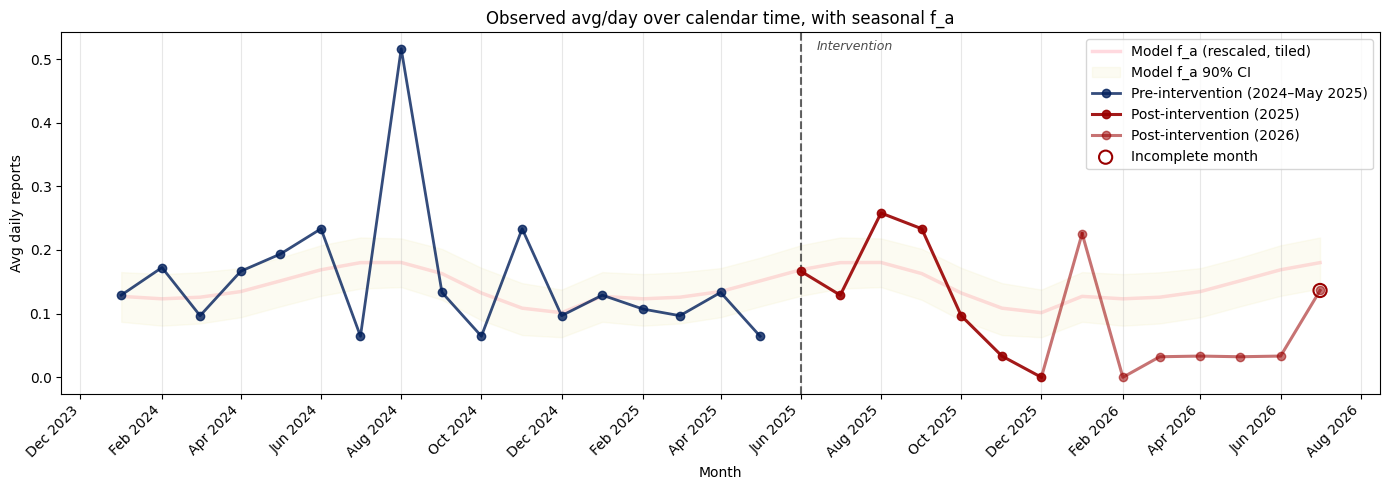

In [44]:
import matplotlib.dates as mdates

obs_cal = obs.copy()
obs_cal["date"] = pd.to_datetime(
    obs_cal["year"].astype(str) + "-" + obs_cal["month"].astype(str) + "-01"
)
obs_cal = obs_cal[obs_cal["date"] >= pd.Timestamp("2024-01-01")].sort_values("date")

fa_mean_map = dict(zip(range(1, 13), fa_mean_month_scaled))
fa_lo_map = dict(zip(range(1, 13), fa_lo_month_scaled))
fa_hi_map = dict(zip(range(1, 13), fa_hi_month_scaled))
obs_cal["fa_mean"] = obs_cal["month"].map(fa_mean_map)
obs_cal["fa_lo"] = obs_cal["month"].map(fa_lo_map)
obs_cal["fa_hi"] = obs_cal["month"].map(fa_hi_map)


intervention_date = pd.Timestamp(year=INTERVENTION_YEAR, month=INTERVENTION_MONTH, day=1)
pre = obs_cal[obs_cal["date"] < intervention_date].copy()
post_2025 = obs_cal[(obs_cal["year"] == 2025) & (obs_cal["date"] >= intervention_date)]
post_2026 = obs_cal[obs_cal["year"] == 2026]

fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(
    obs_cal["date"], obs_cal["fa_mean"],
    linewidth=2.5, color="pink", alpha=0.6,
    label="Model f_a (rescaled, tiled)", zorder=1
)
ax.fill_between(
    obs_cal["date"], obs_cal["fa_lo"], obs_cal["fa_hi"],
    alpha=0.15, color="palegoldenrod",
    label="Model f_a 90% CI", zorder=1
)

ax.plot(
    pre["date"], pre["avg_per_day"],
    marker="o", label="Pre-intervention (2024–May 2025)",
    color="#011f5b", alpha=0.8, linewidth=2, zorder=3
)
ax.plot(
    post_2025["date"], post_2025["avg_per_day"],
    marker="o", label="Post-intervention (2025)",
    color="#990000", alpha=0.9, linewidth=2.2, zorder=4
)
if len(post_2025) and len(post_2026):
    ax.plot(
        [post_2025["date"].iloc[-1], post_2026["date"].iloc[0]],
        [post_2025["avg_per_day"].iloc[-1], post_2026["avg_per_day"].iloc[0]],
        color="#990000", alpha=0.55, linewidth=2.2, zorder=3
    )
ax.plot(
    post_2026["date"], post_2026["avg_per_day"],
    marker="o", label="Post-intervention (2026)",
    color="#990000", alpha=0.55, linewidth=2.2, zorder=4
)

inc = obs_cal[obs_cal["incomplete"]]
if len(inc):
    ax.scatter(
        inc["date"], inc["avg_per_day"],
        s=90, facecolors="none", edgecolors="#990000",
        linewidths=1.5, zorder=5, label="Incomplete month"
    )

ax.axvline(intervention_date, color="black", linestyle="--", linewidth=1.5, alpha=0.6)
ymin, ymax = ax.get_ylim()
ax.text(
    intervention_date + pd.Timedelta(days=12), ymax * 0.95, "Intervention",
    fontsize=9, style="italic", alpha=0.7
)

ax.set_xlabel("Month")
ax.set_ylabel("Avg daily reports")
ax.set_title("Observed avg/day over calendar time, with seasonal f_a")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
plt.setp(ax.get_xticklabels(), rotation=45, ha="right")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()


## Percent decrease vs model expectation (`f_a`)

WPF headline uses the model baseline, with **September included**:

`% decrease = (effect / model expected rate) × 100`

- **effect** = mean(`f_a` − observed avg/day) over post-intervention months  
- **model expected rate** = mean(`f_a`) over those same months  

That is the advantage of the Hawkes seasonal component: expected rate is the model’s month-specific `f_a`, not a raw historical average. Complete months only (July 2026 dropped). September 2025 stays in the headline; a no-September row is shown only as sensitivity (that is where an earlier ~34% figure would have come from).



POST-INTERVENTION vs MODEL f_a BASELINE
Period     Month         Obs      f_a      Diff   % red.
------------------------------------------------------------------------------------------------
2025       Jun         0.167    0.169    -0.002     1.3%
2025       Jul         0.129    0.180    -0.051    28.4%
2025       Aug         0.258    0.180     0.078   -43.1%
2025       Sep         0.233    0.163     0.070   -43.2%
2025       Oct         0.097    0.132    -0.036    26.9%
2025       Nov         0.033    0.109    -0.075    69.3%
2025       Dec         0.000    0.101    -0.101   100.0%
2026       Jan         0.226    0.127     0.099   -77.6%
2026       Feb         0.000    0.123    -0.123   100.0%
2026       Mar         0.032    0.126    -0.094    74.4%
2026       Apr         0.033    0.135    -0.101    75.3%
2026       May         0.032    0.151    -0.119    78.7%
2026       Jun         0.033    0.169    -0.136    80.3%
2026       Jul ~       0.136    0.180    -0.044    24.3%
--------

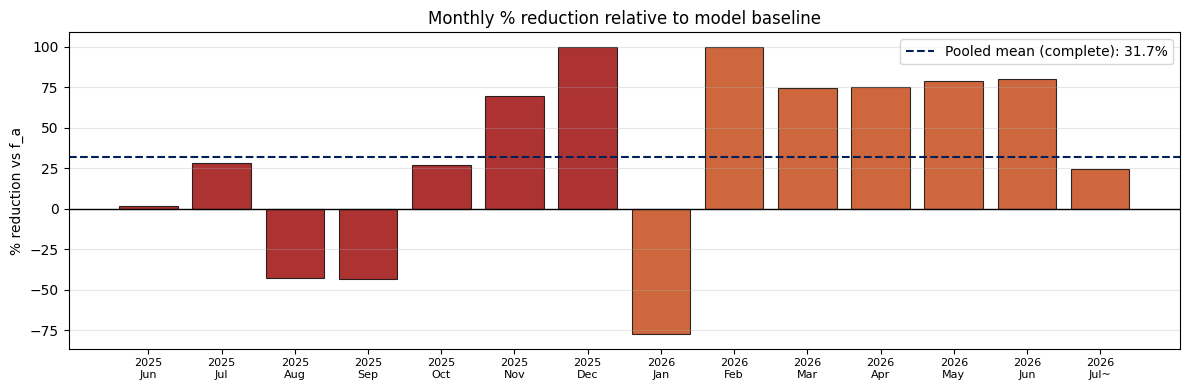

In [38]:
model_baseline = dict(zip(range(1, 13), fa_mean_month_scaled))

post = obs[
    (obs["year"] > INTERVENTION_YEAR)
    | ((obs["year"] == INTERVENTION_YEAR) & (obs["month"] >= INTERVENTION_MONTH))
].copy()
post["expected"] = post["month"].map(model_baseline)
post["effect"] = post["expected"] - post["avg_per_day"]
post["pct_decrease"] = np.where(
    post["expected"] > 1e-8,
    post["effect"] / post["expected"] * 100,
    np.nan,
)


def percent_decrease_vs_model(g, label):
    g = g.copy()
    n = len(g)
    effect = g["effect"].mean()
    expected = g["expected"].mean()
    obs_mean = g["avg_per_day"].mean()
    pct = effect / expected * 100 if expected > 1e-8 else np.nan
    se = g["effect"].std(ddof=1) / np.sqrt(n)
    t_stat, p_value = stats.ttest_1samp(g["effect"].to_numpy(), 0)
    tcrit = stats.t.ppf(0.975, n - 1)
    pct_lo = (effect - tcrit * se) / expected * 100
    pct_hi = (effect + tcrit * se) / expected * 100
    sig = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "ns"
    print(f"{label}")
    print(f"  n months          = {n}")
    print(f"  observed rate     = {obs_mean:.3f} /day")
    print(f"  model expected    = {expected:.3f} /day")
    print(f"  effect            = {effect:+.3f} /day   (expected − observed)")
    print(f"  % decrease        = {pct:.1f}%")
    print(f"  95% CI            = [{pct_lo:.1f}%, {pct_hi:.1f}%]")
    print(f"  t-test vs 0       = t={t_stat:.2f}, p={p_value:.4f} {sig}")
    print()
    return pct

print("=" * 80)
print("% decrease = (effect / model expected rate) × 100")
print("effect = mean(f_a − observed); expected = mean(f_a)")
print("=" * 80)
print(f"{'Period':<10} {'Month':<8} {'Obs':>8} {'Expected':>10} {'Effect':>9} {'% dec.':>8}")
print("-" * 80)
for _, row in post.sort_values(["year", "month"]).iterrows():
    flag = " ~" if row["incomplete"] else ""
    print(
        f"{int(row['year']):<10} {calendar.month_abbr[int(row['month'])]+flag:<8} "
        f"{row['avg_per_day']:8.3f} {row['expected']:10.3f} {row['effect']:9.3f} "
        f"{row['pct_decrease']:7.1f}%"
    )
print("-" * 80)
print("~ = incomplete month (not in headline)")
print()

post_complete = post[~post["incomplete"]].copy()
post_2025 = post_complete[post_complete["year"] == 2025]
post_2026 = post_complete[post_complete["year"] == 2026]
post_2025_nose = post_2025[post_2025["month"] != 9]
post_all_nose = post_complete[post_complete["month"] != 9]

print("HEADLINE (September included)")
print("-" * 80)
pct_all = percent_decrease_vs_model(
    post_complete, "All post-intervention complete months, 2025–2026 (incl. Sep)"
)
percent_decrease_vs_model(post_2025, "2025 Jun–Dec only (incl. Sep)")
percent_decrease_vs_model(post_2026, "2026 complete months")

print("SENSITIVITY (September excluded — old notebook)")
print("-" * 80)
percent_decrease_vs_model(post_all_nose, "All post complete, excl. Sep")
percent_decrease_vs_model(post_2025_nose, "2025 excl. Sep")

print("=" * 80)
print(
    f"WPF headline: {pct_all:.1f}% decrease vs model expected rate "
    f"(September included, complete months)."
)
print("=" * 80)

fig, ax = plt.subplots(figsize=(12, 4))
x = np.arange(len(post))
colors = ["#990000" if y == 2025 else "#c2410c" for y in post["year"]]
ax.bar(x, post["pct_decrease"], color=colors, alpha=0.8, edgecolor="black", linewidth=0.8)
ax.axhline(0, color="black", linewidth=1)
ax.axhline(pct_all, color="#011f5b", linestyle="--", linewidth=1.5,
           label=f"Headline % decrease: {pct_all:.1f}%")
ax.set_xticks(x)
ax.set_xticklabels(
    [f"{int(y)}\n{calendar.month_abbr[int(m)]}" + ("~" if inc else "")
     for y, m, inc in zip(post["year"], post["month"], post["incomplete"])],
    fontsize=8,
)
ax.set_ylabel("% decrease vs model expected")
ax.set_title("% decrease = (effect / model expected rate) × 100")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()


## Month-by-month comparison vs historical average

Historical baseline: Jan–May uses 2021–2025; Jun–Dec uses 2021–2024. 2025 is compared for Jun–Dec; 2026 for every available month.


In [29]:
def historical_values_for_month(month):
    if month < INTERVENTION_MONTH:
        return obs_pre_intervention.loc[obs_pre_intervention["month"] == month, "avg_per_day"].values
    return obs_post_intervention_historical.loc[
        obs_post_intervention_historical["month"] == month, "avg_per_day"
    ].values

results = []
for post_year, post_obs in [(2025, obs_post_intervention_2025), (2026, obs_post_intervention_2026)]:
    for _, row in post_obs.iterrows():
        month = int(row["month"])
        current_value = float(row["avg_per_day"])
        historical_vals = historical_values_for_month(month)
        if len(historical_vals) < 2:
            continue

        hist_mean = np.mean(historical_vals)
        hist_std = np.std(historical_vals, ddof=1)
        diff = current_value - hist_mean
        cohens_d = diff / hist_std if hist_std > 0 else np.nan
        z_score = cohens_d
        p_value = 2 * (1 - stats.norm.cdf(abs(z_score))) if not np.isnan(z_score) else np.nan
        se = hist_std / np.sqrt(len(historical_vals))

        results.append({
            "post_year": post_year,
            "month": month,
            "month_name": calendar.month_abbr[month],
            "month_centered": month - INTERVENTION_MONTH,
            "n_historical": len(historical_vals),
            "historical_mean": hist_mean,
            "historical_std": hist_std,
            "ci_lower": hist_mean - 1.96 * se,
            "ci_upper": hist_mean + 1.96 * se,
            "value_post": current_value,
            "difference": diff,
            "cohens_d": cohens_d,
            "z_score": z_score,
            "p_value": p_value,
            "incomplete": bool(row["incomplete"]),
        })

results_df = pd.DataFrame(results).sort_values(["month", "post_year"]).reset_index(drop=True)

print("=" * 90)
print("MONTH-BY-MONTH COMPARISON (raw avg/day)")
print("=" * 90)
print(f"{'Year':<6} {'Month':<8} {'N_hist':<7} {'Hist_Mean':<10} {'Post':<10} {'Diff':<10} {'Cohen_d':<10} {'p-value':<10} {'Sig':<5}")
print("-" * 90)
for _, row in results_df.iterrows():
    sig = "***" if row["p_value"] < 0.001 else "**" if row["p_value"] < 0.01 else "*" if row["p_value"] < 0.05 else ""
    flag = " ~" if row["incomplete"] else ""
    print(
        f"{int(row['post_year']):<6} {row['month_name']+flag:<8} {row['n_historical']:<7.0f} "
        f"{row['historical_mean']:>9.3f} {row['value_post']:>9.3f} {row['difference']:>9.3f} "
        f"{row['cohens_d']:>9.3f} {row['p_value']:>9.4f} {sig:<5}"
    )
print("-" * 90)
print("~ = incomplete month (avg/day uses elapsed days)")

for post_year, g in results_df.groupby("post_year"):
    overall_diff = g["difference"].mean()
    overall_d = g["cohens_d"].mean()
    z_combined = g["z_score"].sum() / np.sqrt(len(g))
    p_combined = 2 * (1 - stats.norm.cdf(abs(z_combined)))
    sig = "***" if p_combined < 0.001 else "**" if p_combined < 0.01 else "*" if p_combined < 0.05 else "ns"
    print(f"\n{int(post_year)} overall: mean diff={overall_diff:.3f}/day, mean d={overall_d:.3f}, combined p={p_combined:.4f} ({sig})")


MONTH-BY-MONTH COMPARISON (raw avg/day)
Year   Month    N_hist  Hist_Mean  Post       Diff       Cohen_d    p-value    Sig  
------------------------------------------------------------------------------------------
2026   Jan      5           0.142     0.226     0.084     0.810    0.4179      
2026   Feb      5           0.077     0.000    -0.077    -1.163    0.2447      
2026   Mar      5           0.103     0.032    -0.071    -1.483    0.1380      
2026   Apr      5           0.180     0.033    -0.147    -1.144    0.2527      
2026   May      5           0.142     0.032    -0.110    -1.059    0.2894      
2025   Jun      4           0.167     0.167    -0.000    -0.000    1.0000      
2026   Jun      4           0.167     0.033    -0.133    -2.828    0.0047 **   
2025   Jul      4           0.121     0.129     0.008     0.051    0.9595      
2026   Jul ~    4           0.121     0.136     0.015     0.097    0.9228      
2025   Aug      4           0.274     0.258    -0.016    -0.084 

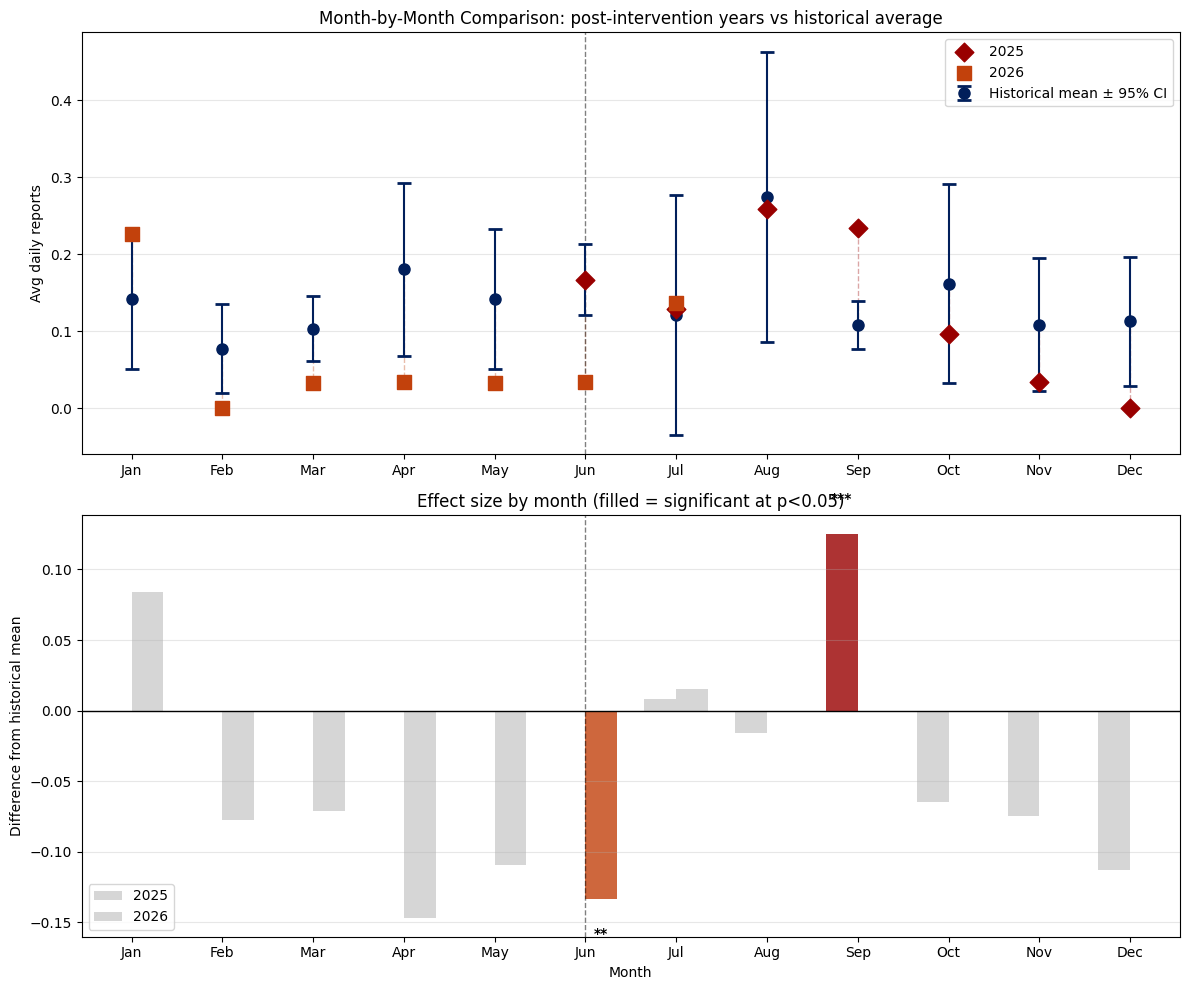


Detailed results table:
 post_year  month month_name  month_centered  n_historical  historical_mean  historical_std  ci_lower  ci_upper  value_post    difference      cohens_d       z_score  p_value  incomplete
      2026      1        Jan              -5             5         0.141935        0.103528  0.051189  0.232682    0.225806  8.387097e-02  8.101300e-01  8.101300e-01 0.417865       False
      2026      2        Feb              -4             5         0.077340        0.066476  0.019071  0.135609    0.000000 -7.733990e-02 -1.163422e+00 -1.163422e+00 0.244658       False
      2026      3        Mar              -3             5         0.103226        0.047846  0.061287  0.145165    0.032258 -7.096774e-02 -1.483240e+00 -1.483240e+00 0.138011       False
      2026      4        Apr              -2             5         0.180000        0.128236  0.067596  0.292404    0.033333 -1.466667e-01 -1.143726e+00 -1.143726e+00 0.252737       False
      2026      5        May            

In [30]:
plot_months = list(range(1, 13))
month_names = [calendar.month_abbr[m] for m in plot_months]
x_pos = np.arange(len(plot_months))

hist_by_month = {}
for m in plot_months:
    vals = historical_values_for_month(m)
    if len(vals) >= 2:
        hist_by_month[m] = {
            "mean": np.mean(vals),
            "std": np.std(vals, ddof=1),
            "n": len(vals),
        }

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

means = [hist_by_month[m]["mean"] if m in hist_by_month else np.nan for m in plot_months]
yerr = [
    1.96 * hist_by_month[m]["std"] / np.sqrt(hist_by_month[m]["n"]) if m in hist_by_month else np.nan
    for m in plot_months
]
ax1.errorbar(
    x_pos, means, yerr=yerr,
    fmt="o", color="#011f5b", markersize=8, capsize=5, capthick=2,
    label="Historical mean ± 95% CI", zorder=3
)

year_style = {
    2025: dict(color="#990000", marker="D", label="2025"),
    2026: dict(color="#c2410c", marker="s", label="2026"),
}
for post_year, style in year_style.items():
    g = results_df[results_df["post_year"] == post_year]
    xs = [plot_months.index(int(m)) for m in g["month"]]
    ax1.scatter(xs, g["value_post"], s=90, zorder=4, **style)
    for x, hist, curr in zip(xs, g["historical_mean"], g["value_post"]):
        ax1.plot([x, x], [hist, curr], color=style["color"], linestyle="--", alpha=0.35, linewidth=1)

ax1.axvline(INTERVENTION_MONTH - 1, color="black", linestyle="--", linewidth=1, alpha=0.5)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(month_names)
ax1.set_ylabel("Avg daily reports")
ax1.set_title("Month-by-Month Comparison: post-intervention years vs historical average")
ax1.legend(loc="upper right")
ax1.grid(True, alpha=0.3, axis="y")

width = 0.35
for post_year, color, offset in [(2025, "#990000", -width/2), (2026, "#c2410c", width/2)]:
    g = results_df[results_df["post_year"] == post_year].set_index("month")
    diffs = [g.loc[m, "difference"] if m in g.index else np.nan for m in plot_months]
    pvals = [g.loc[m, "p_value"] if m in g.index else np.nan for m in plot_months]
    bar_colors = [color if (pd.notna(p) and p < 0.05) else "#cccccc" for p in pvals]
    ax2.bar(x_pos + offset, diffs, width=width, color=bar_colors, alpha=0.8, label=str(post_year))
    for x, diff, p in zip(x_pos + offset, diffs, pvals):
        if not pd.notna(diff) or not pd.notna(p):
            continue
        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
        if sig:
            ax2.text(x, diff + (0.02 if diff > 0 else -0.02), sig,
                     ha="center", va="bottom" if diff > 0 else "top",
                     fontsize=10, fontweight="bold")

ax2.axhline(0, color="black", linewidth=1)
ax2.axvline(INTERVENTION_MONTH - 1, color="black", linestyle="--", linewidth=1, alpha=0.5)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(month_names)
ax2.set_ylabel("Difference from historical mean")
ax2.set_xlabel("Month")
ax2.set_title("Effect size by month (filled = significant at p<0.05)")
ax2.legend()
ax2.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

print("\nDetailed results table:")
print(results_df.to_string(index=False))


## Overall significance of the intervention

Month-by-month (above) asks whether **that calendar month** is unusual vs the same month in earlier years. That is the right comparison for seasonal data.

The overall claim uses those same monthly differences, then a **one-sample t-test vs 0** (original fence notebook). 2025 Jun–Dec excluding September was previously not quite significant (*p* ≈ 0.08). Adding 2026 should increase power. Stouffer’s combined *p* on the month-by-month *z*-scores is shown as a second summary; it is not a substitute for the t-test.


In [41]:
def sig_stars(p):
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"

def ttest_diffs(diffs, label):
    diffs = np.asarray(diffs, dtype=float)
    diffs = diffs[np.isfinite(diffs)]
    n = len(diffs)
    if n < 2:
        print(f"{label:<42} n={n}  (need ≥2 months)")
        return np.nan
    mean_diff = float(np.mean(diffs))
    std_diff = float(np.std(diffs, ddof=1))
    se = std_diff / np.sqrt(n)
    t_stat, p_value = stats.ttest_1samp(diffs, 0)
    tcrit = stats.t.ppf(0.975, n - 1)
    ci_lo, ci_hi = mean_diff - tcrit * se, mean_diff + tcrit * se
    print(
        f"{label:<42} n={n:<3}  mean Δ={mean_diff:+.3f}/day  "
        f"95% CI [{ci_lo:+.3f}, {ci_hi:+.3f}]  t={t_stat:+.2f}  "
        f"p={p_value:.4f} {sig_stars(p_value)}"
    )
    return p_value

def stouffer_p(z):
    z = np.asarray(z, dtype=float)
    z = z[np.isfinite(z)]
    z_comb = z.sum() / np.sqrt(len(z))
    return float(2 * (1 - stats.norm.cdf(abs(z_comb)))), float(z_comb)

res = results_df.copy()
res_complete = res[~res["incomplete"]].copy()
res_2025 = res_complete[res_complete["post_year"] == 2025]
res_2026 = res_complete[res_complete["post_year"] == 2026]
res_2025_nose = res_2025[res_2025["month"] != 9]
res_all_nose = res_complete[res_complete["month"] != 9]

print("=" * 100)
print("A. MONTH-BY-MONTH vs HISTORICAL SAME MONTH  →  one-sample t-test on monthly differences")
print("    H0: mean(post − historical_same_month) = 0")
print("=" * 100)
p_2025 = ttest_diffs(res_2025["difference"], "2025 Jun–Dec (original window)")
p_2025_nose = ttest_diffs(res_2025_nose["difference"], "2025 excl. Sep (previous 'not quite')")
p_2026 = ttest_diffs(res_2026["difference"], "2026 complete months")
p_all = ttest_diffs(res_complete["difference"], "All post complete (2025–2026)")
p_all_nose = ttest_diffs(res_all_nose["difference"], "All post complete excl. Sep")
print()

print("B. Same monthly z-scores, Stouffer combined p (what the table above reports by year)")
print("-" * 100)
for label, g in [
    ("2025 Jun–Dec", res_2025),
    ("2025 excl. Sep", res_2025_nose),
    ("2026 complete", res_2026),
    ("All post complete", res_complete),
    ("All post complete excl. Sep", res_all_nose),
]:
    p_s, z_s = stouffer_p(g["z_score"])
    print(f"{label:<42} n={len(g):<3}  z_comb={z_s:+.2f}  p={p_s:.4f} {sig_stars(p_s)}")
print()

model_baseline = dict(zip(range(1, 13), fa_mean_month_scaled))
post_m = obs[
    (obs["year"] > INTERVENTION_YEAR)
    | ((obs["year"] == INTERVENTION_YEAR) & (obs["month"] >= INTERVENTION_MONTH))
].copy()
post_m = post_m[~post_m["incomplete"]].copy()
post_m["baseline"] = post_m["month"].map(model_baseline)
post_m["diff_fa"] = post_m["avg_per_day"] - post_m["baseline"]
post_m["pct_red"] = np.where(
    post_m["baseline"] > 1e-8,
    (post_m["baseline"] - post_m["avg_per_day"]) / post_m["baseline"] * 100,
    np.nan,
)

print("=" * 100)
print("C. vs MODEL f_a BASELINE  →  one-sample t-test on (observed − f_a)")
print("    H0: mean(observed − f_a) = 0   (negative mean = reduction)")
print("=" * 100)
ttest_diffs(post_m.loc[post_m["year"] == 2025, "diff_fa"], "2025 vs f_a")
ttest_diffs(post_m.loc[post_m["year"] == 2026, "diff_fa"], "2026 vs f_a")
ttest_diffs(post_m["diff_fa"], "All post complete vs f_a")
ttest_diffs(post_m.loc[post_m["month"] != 9, "diff_fa"], "All post complete vs f_a, excl. Sep")

mean_obs = post_m["avg_per_day"].mean()
mean_fa = post_m["baseline"].mean()
effect = mean_fa - mean_obs
pct_decrease = effect / mean_fa * 100
t_stat, p_fa = stats.ttest_1samp(post_m["diff_fa"].to_numpy(), 0)
print("-" * 100)
print("C headline: % decrease = (effect / model expected rate) × 100")
print(
    f"  effect={effect:+.3f}/day, expected={mean_fa:.3f}/day, "
    f"% decrease={pct_decrease:.1f}%, t-test p={p_fa:.4f} {sig_stars(p_fa)} "
    f"(September included)."
)
print("Use panel A/B for historical same-month significance. Use this cell's % decrease vs f_a for WPF.")
print("=" * 100)



A. MONTH-BY-MONTH vs HISTORICAL SAME MONTH  →  one-sample t-test on monthly differences
    H0: mean(post − historical_same_month) = 0
2025 Jun–Dec (original window)             n=7    mean Δ=-0.019/day  95% CI [-0.091, +0.052]  t=-0.66  p=0.5323 ns
2025 excl. Sep (previous 'not quite')      n=6    mean Δ=-0.043/day  95% CI [-0.094, +0.007]  t=-2.21  p=0.0779 ns
2026 complete months                       n=6    mean Δ=-0.076/day  95% CI [-0.163, +0.012]  t=-2.22  p=0.0775 ns
All post complete (2025–2026)              n=13   mean Δ=-0.045/day  95% CI [-0.095, +0.004]  t=-1.99  p=0.0700 ns
All post complete excl. Sep                n=12   mean Δ=-0.060/day  95% CI [-0.102, -0.017]  t=-3.07  p=0.0107 *

B. Same monthly z-scores, Stouffer combined p (what the table above reports by year)
----------------------------------------------------------------------------------------------------
2025 Jun–Dec                               n=7    z_comb=+0.46  p=0.6459 ns
2025 excl. Sep              